# <span style="color:red"> **LSN - Esercitazione 03**
### <span style="color:green"> 20.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

## <span style="color:blue">**Esercizio 03.1**

Si è analizzato il pricing delle opzioni finanziarie mediante simulazione Monte Carlo, basandosi sul modello di Black-Scholes. Un'opzione rappresenta un contratto che conferisce al possessore il diritto, ma non l'obbligo, di acquistare (call) o vendere (put) un asset sottostante a un prezzo prefissato $K$ entro una data scadenza $T$.

Il valore intrinseco delle opzioni alla scadenza è dato da:
$$
\text{Payoff call} = \max(S(T) - K, 0)
$$
$$
\text{Payoff put} = \max(K - S(T), 0)
$$
dove $S(T)$ indica il prezzo dell'asset al tempo $T$. Per riportarlo al tempo attuale, il profitto va scontato: infatti, va moltiplicato per un esponenziale con esponente negativo $e^{-rT}$, che tiene conto del fatto che il valore del denaro non è costante nel tempo.

Si è assunto che l'evoluzione temporale del prezzo segua un moto browniano geometrico (GBM):
$$
S(t) = S(0) \cdot \exp\left[\left(r - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]
$$

Dove:
- $r = 0.1$ rappresenta il tasso di interesse privo di rischio
- $\sigma = 0.25$ esprime la volatilità del titolo
- $W_t$ è un processo di Wiener standard con incrementi $W(t)\sim\mathcal{N}(0,t)$

Si è valutato il prezzo dell'opzione tramite simulazione Monte Carlo, con $100$ blocchi, e per un totale di $10^5$ repliche del processo stocastico.
1. Campionamento Diretto del Prezzo Finale

Si è generato direttamente il valore $S(T)$ mediante la formula chiusa:
$$
S(T) = S_0 \exp\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma z\sqrt{T}\right]
$$
con $z \sim \mathcal{N}(0,1)$.

2. Campionamento Discretizzato del Percorso

Si è suddiviso l'intervallo $[0,T]$ in $N=100$ sottointervalli, simulando l'evoluzione incrementale:
$$
S_{t+\Delta t} = S_t \exp\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma z\sqrt{\Delta t}\right]
$$
Questa approssimazione permette di catturare la dinamica temporale del prezzo, risultando particolarmente utile per opzioni path-dependent.

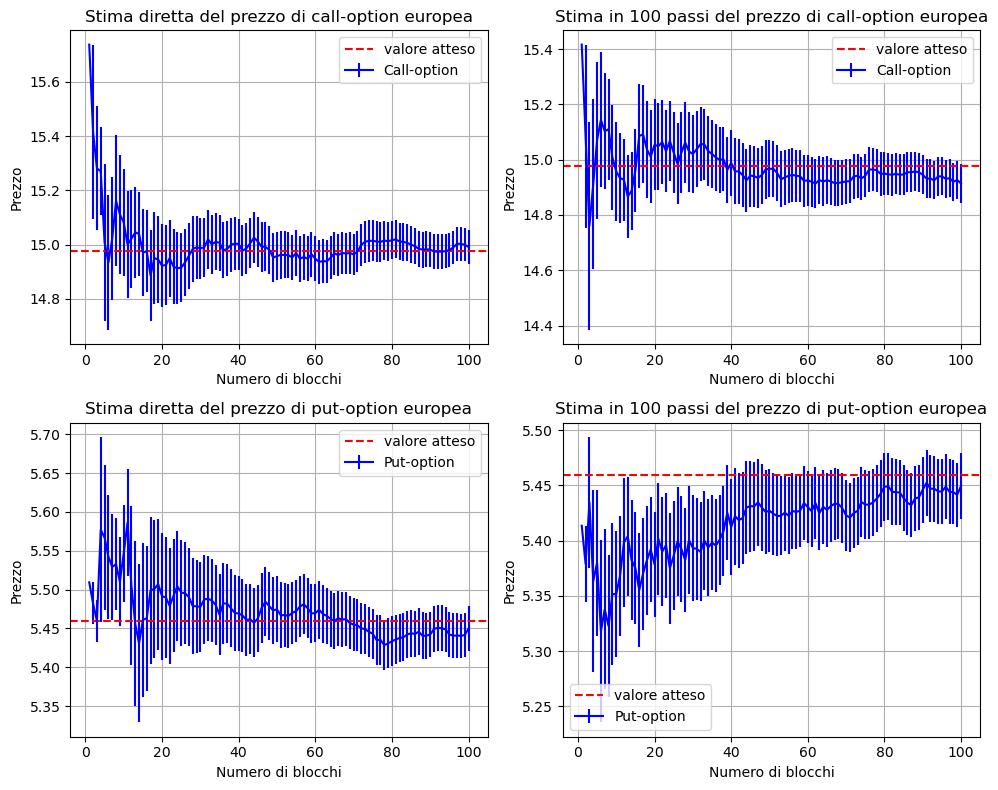

In [31]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# Carico i dati dal file
data_call_dir = np.loadtxt("03.1/data_call_dir.dat")
data_put_dir = np.loadtxt("03.1/data_put_dir.dat")
data_call_discr = np.loadtxt("03.1/data_call_discr.dat")
data_put_discr = np.loadtxt("03.1/data_put_discr.dat")

# Estraggo le colonne di dati
x = data_call_dir[:, 0]   # Prima colonna: contiene il numero di blocchi (uso la stessa per tutti i plot)
y_call_dir = data_call_dir[:, 2]   # Terza colonna: prezzo dell'opzione
y_put_dir = data_put_dir[:, 2]   # Terza colonna: prezzo dell'opzione
err_call_dir = data_call_dir[:, 3] # Quarta colonna: errore (deviazione standard)
err_put_dir = data_put_dir[:, 3]
y_call_discr = data_call_discr[:, 2]   # Terza colonna: prezzo dell'opzione
y_put_discr = data_put_discr[:, 2]   # Terza colonna: prezzo dell'opzione
err_call_discr = data_call_discr[:, 3] # Quarta colonna: errore (deviazione standard)
err_put_discr = data_put_discr[:, 3]


# Creazione di una figura con 2 righe e 2 colonne
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot call (diretto)
axes[0,0].errorbar(x, y_call_dir, yerr=err_call_dir,label="Call-option",color='b')
axes[0,0].set_xlabel("Numero di blocchi")
axes[0,0].set_ylabel("Prezzo")
axes[0,0].set_title("Stima diretta del prezzo di call-option europea")
axes[0,0].axhline(y=14.975790778311286, color='r', linestyle='--', label="valore atteso")
axes[0,0].legend()
axes[0,0].grid(True)

# Plot call (100 passi)
axes[0,1].errorbar(x, y_call_discr, yerr=err_call_discr,label="Call-option",color='b')
axes[0,1].set_xlabel("Numero di blocchi")
axes[0,1].set_ylabel("Prezzo")
axes[0,1].set_title("Stima in 100 passi del prezzo di call-option europea")
axes[0,1].axhline(y=14.975790778311286, color='r', linestyle='--', label="valore atteso")
axes[0,1].legend()
axes[0,1].grid(True)

# Plot put (diretto)
axes[1,0].errorbar(x, y_put_dir, yerr=err_put_dir,label="Put-option",color='b')
axes[1,0].set_xlabel("Numero di blocchi")
axes[1,0].set_ylabel("Prezzo")
axes[1,0].set_title("Stima diretta del prezzo di put-option europea")
axes[1,0].axhline(y=5.4595325819072364, color='r', linestyle='--', label="valore atteso")
axes[1,0].legend()
axes[1,0].grid(True)

# Plot call (100 passi)
axes[1,1].errorbar(x, y_put_discr, yerr=err_put_discr,label="Put-option",color='b')
axes[1,1].set_xlabel("Numero di blocchi")
axes[1,1].set_ylabel("Prezzo")
axes[1,1].set_title("Stima in 100 passi del prezzo di put-option europea")
axes[1,1].axhline(y=5.4595325819072364, color='r', linestyle='--', label="valore atteso")
axes[1,1].legend()
axes[1,1].grid(True)


# Layout per evitare sovrapposizioni
plt.tight_layout()
plt.show()


I valori ottenuti risultano statisticamente compatibili con i valori stimati con le soluzioni analitiche ottenute da Black-Sholes, ovvero $14.975790778311286$ per la call-otpion e $5.4595325819072364$ per la put-option.